In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
patients_df = pd.read_csv("../data/processed/patients.csv")

In [4]:
# Preview the dataset
patients_df.head()

,patient_id,study_id,condition,label,disease_comment,age_at_diagnosis,age,height_cm,weight_kg,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor
0,1,PADS,Healthy,0,-,56,56,173,78,male,right,True,True,Unknown
1,2,PADS,Other Movement Disorders,2,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect
2,3,PADS,Healthy,0,-,45,45,170,78,female,right,False,NaN,Unknown
3,4,PADS,Parkinson's,1,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect
4,5,PADS,Parkinson's,1,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown


In [5]:
# Display dataset dimensions
print(f"Dataset Shape: {patients_df.shape}")

Dataset Shape: (469, 14)


In [6]:
# Display dataset information
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   patient_id                         469 non-null    int64 
 1   study_id                           469 non-null    object
 2   condition                          469 non-null    object
 3   label                              469 non-null    int64 
 4   disease_comment                    469 non-null    object
 5   age_at_diagnosis                   469 non-null    int64 
 6   age                                469 non-null    int64 
 7   height_cm                          469 non-null    int64 
 8   weight_kg                          469 non-null    int64 
 9   gender                             469 non-null    object
 10  handedness                         469 non-null    object
 11  appearance_in_kinship              469 non-null    bool  
 12  appearan

In [7]:
# Check for missing values
missing_values = patients_df.isnull().sum()

print("Missing Values Per Column")
print("-" * 30)
print(missing_values)

Missing Values Per Column
------------------------------
patient_id                             0
study_id                               0
condition                              0
label                                  0
disease_comment                        0
age_at_diagnosis                       0
age                                    0
height_cm                              0
weight_kg                              0
gender                                 0
handedness                             0
appearance_in_kinship                  0
appearance_in_first_grade_kinship    288
effect_of_alcohol_on_tremor            0
dtype: int64


In [8]:
# Create target classes 
patients_df["Target Class"] = patients_df["condition"].replace({
    "Parkinson's": "Parkinson's Disease",
    "Essential Tremor": "Other Movement Disorders",
    "Atypical Parkinsonism": "Other Movement Disorders",
    "Multiple Sclerosis": "Other Movement Disorders"
})

# Generate participant count table
participant_counts = (
    patients_df["Target Class"]
    .value_counts()
    .rename_axis("Target Class")
    .reset_index(name="Participant Count")
)

# Calculate percentage distribution
participant_counts["Percentage (%)"] = (
    participant_counts["Participant Count"]
    / participant_counts["Participant Count"].sum()
    * 100
).round(2)

# Display participant count summary
print(f"Total Participants : {len(patients_df)}")
print(f"Total Features     : {patients_df.shape[1]}")
print(f"Target Classes     : {participant_counts.shape[0]}")

# Display participant count table
participant_counts

Total Participants : 469
Total Features     : 15
Target Classes     : 3


,Target Class,Participant Count,Percentage (%)
0,Parkinson's Disease,276,58.85
1,Other Movement Disorders,114,24.31
2,Healthy,79,16.84


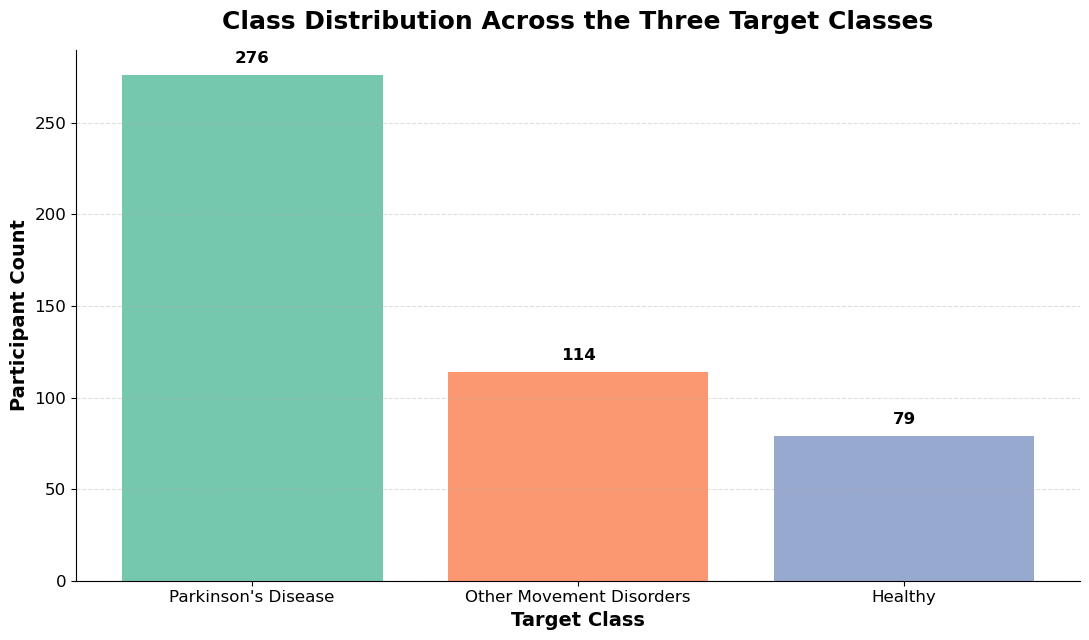

In [14]:
# Create class distribution bar chart
plt.figure(figsize=(11, 6.5))

# Set bar colors
colors = plt.cm.Set2.colors

# Create bar chart
bars = plt.bar(
    participant_counts["Target Class"],
    participant_counts["Participant Count"],
    color=colors,
    alpha=0.9
)

# Add participant count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Chart title
plt.title(
    "Class Distribution Across the Three Target Classes",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Target Class",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Participant Count",
    fontsize=14,
    fontweight="bold"
)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

In [10]:
# Generate OMD subtype table
omd_subtypes = (
    patients_df[patients_df["Target Class"] == "Other Movement Disorders"]["condition"]
    .value_counts()
    .rename_axis("OMD Subtype")
    .reset_index(name="Participant Count")
)

# Calculate percentage distribution within the OMD class
omd_subtypes["Percentage (%)"] = (
    omd_subtypes["Participant Count"]
    / omd_subtypes["Participant Count"].sum()
    * 100
).round(2)

# Display OMD subtype table
omd_subtypes

,OMD Subtype,Participant Count,Percentage (%)
0,Other Movement Disorders,60,52.63
1,Essential Tremor,28,24.56
2,Atypical Parkinsonism,15,13.16
3,Multiple Sclerosis,11,9.65


In [11]:
patients_df.columns

Index(['patient_id', 'study_id', 'condition', 'label', 'disease_comment',
       'age_at_diagnosis', 'age', 'height_cm', 'weight_kg', 'gender',
       'handedness', 'appearance_in_kinship',
       'appearance_in_first_grade_kinship', 'effect_of_alcohol_on_tremor',
       'Target Class'],
      dtype='object')

In [12]:
pd.crosstab(patients_df["condition"], patients_df["label"])

label,0,1,2
condition,,,
Atypical Parkinsonism,0,0,15
Essential Tremor,0,0,28
Healthy,79,0,0
Multiple Sclerosis,0,0,11
Other Movement Disorders,0,0,60
Parkinson's,0,276,0
